In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xml.etree.ElementTree as ET
import shapely
import cartopy
import pyproj
import numpy
from math import sin,cos,radians
from pathlib import Path
from datetime import datetime

In [2]:
title = "Seduisant WNR Series 1 3/25/2026"
outfileBase = "Seduisant WNR Series 1 2026-03-25"
outputPath = "./output/Seduisant"

waypointFile = "./tracks/2020LakePontchartrainRacingMarks.gpx"
trackFile = "./tracks/2026-03-25 Seduisant.gpx"
windFile = "./windData/burl1_2026-04-15.pickle"
proj = cartopy.crs.Mercator()
buffer = 0.25 / 60 #buffer in nautical miles
figsize = (25,10)
nm2Meter = 1852.0
norm = mpl.colors.Normalize(vmin=5, vmax = 9, clip=True)
colorbarTicks = numpy.arange(norm.vmin,norm.vmax+0.001,1.0)
colorMap = mpl.cm.magma

In [3]:
wgs84 = pyproj.crs.CRS.from_string('WGS84')
utm = pyproj.crs.CRS.from_string('EPSG:32615')

In [4]:
Path(outputPath).mkdir(exist_ok=True,parents=True)

In [5]:
waypointXML = ET.parse(waypointFile)

In [6]:
wptList = []
for child in waypointXML.getroot():
    data = {
                'name':child.find('{http://www.topografix.com/GPX/1/1}name').text,
                'geometry':shapely.Point(child.attrib['lon'],child.attrib['lat'])
    }
    
    wptList.append(data)

waypointGdf = gpd.GeoDataFrame(data= pd.DataFrame.from_dict(wptList), geometry='geometry', crs=wgs84)

In [7]:
waypointGdf.drop_duplicates(subset=['name'], inplace=True)

In [8]:
waypointGdf['name'] = waypointGdf['name'].str.replace('"','').str.replace('SYC ','')

In [9]:
waypointGdf.set_index('name', inplace=True)

In [10]:
trkXML = ET.parse(trackFile)

In [11]:
trkSegXML = trkXML.getroot().find('{http://www.topografix.com/GPX/1/1}trk').\
    find('{http://www.topografix.com/GPX/1/1}trkseg')

In [12]:
trkList = []
for child in trkSegXML:
    data = {
                'time':child.find('{http://www.topografix.com/GPX/1/1}time').text,
                'geometry':shapely.Point(child.attrib['lon'],child.attrib['lat'])
           }
    
    trkList.append(data)

trkGdf = gpd.GeoDataFrame(data=pd.DataFrame.from_dict(trkList), geometry='geometry', crs=wgs84)

In [13]:
trkGdf['time'] = pd.to_datetime( trkGdf['time'] ).dt.tz_convert('US/Central')
print(f"Start time {trkGdf['time'].min()}")

Start time 2026-03-25 18:40:01-05:00


In [14]:
trkGdf['timeDelta'] = trkGdf['time'] - trkGdf['time'].shift(1)
trkGdf['timeCumsum'] = trkGdf['timeDelta'].cumsum()
print(f"Mean time between measure {trkGdf['timeDelta'].mean()}")

Mean time between measure 0 days 00:00:08.179906


In [15]:
geod = pyproj.Geod(ellps='clrk66')
print(f"Total distance {geod.line_length(trkGdf['geometry'].x, trkGdf['geometry'].y) / nm2Meter}nm")

Total distance 6.458018489470264nm


In [16]:
trkGdf['bearing'] = geod.inv(trkGdf['geometry'].x,trkGdf['geometry'].y, trkGdf['geometry'].shift(1).x, trkGdf['geometry'].shift(1).y)[1]

In [17]:
mask = trkGdf['bearing'] < 0
trkGdf.loc[mask, 'bearing'] = trkGdf['bearing'][mask] + 360.0

In [18]:
trkGdf['delta_distance'] = numpy.nan
trkGdf.loc[1:,'delta_distance'] = geod.line_lengths(trkGdf['geometry'].x, trkGdf['geometry'].y) / nm2Meter

In [19]:
trkGdf['dist_cumsum'] = trkGdf['delta_distance'].cumsum()

In [20]:
trkGdf['delta_distance'].sum()

np.float64(6.458018489470264)

In [21]:
trkGdf['speed'] = (60.0 * 60.0 * trkGdf['delta_distance']) / trkGdf['timeDelta'].dt.total_seconds()

In [22]:
print(f"speed max:{trkGdf['speed'].max()}\tmin:{trkGdf['speed'].min()}\tmean:{trkGdf['speed'].mean()}")

speed max:8.564932155625439	min:3.7889328869408376	mean:6.653958514822466


In [23]:
dirArrowTimes = pd.date_range(start=trkGdf.loc[0,'time'], end=trkGdf.loc[trkGdf.index[-1],'time'], periods=7)[1:]

In [24]:
trkGdf.set_index('time',inplace=True)

In [25]:
trkGdf.head()

,geometry,timeDelta,timeCumsum,bearing,delta_distance,dist_cumsum,speed
time,,,,,,,
2026-03-25 18:40:01-05:00,POINT (-90.10379 30.03262),NaT,NaT,NaN,NaN,NaN,NaN
2026-03-25 18:40:09-05:00,POINT (-90.10368 30.03276),0 days 00:00:08,0 days 00:00:08,36.196285,0.009891,0.009891,4.450853
2026-03-25 18:40:13-05:00,POINT (-90.10358 30.03283),0 days 00:00:04,0 days 00:00:12,50.823435,0.006504,0.016395,5.853857
2026-03-25 18:40:19-05:00,POINT (-90.10344 30.03293),0 days 00:00:06,0 days 00:00:18,49.269116,0.009834,0.026229,5.900276
2026-03-25 18:40:32-05:00,POINT (-90.10313 30.03319),0 days 00:00:13,0 days 00:00:31,46.393108,0.022367,0.048596,6.194027


In [26]:
windDf = pd.read_pickle(windFile)
mask = numpy.logical_and( (windDf.index >= trkGdf.index.min()),\
                        windDf.index <= trkGdf.index.max())
windDf = windDf[mask].copy()
medianWind = windDf['WDIR'].median()
meanWindSpeed = windDf['WSPD'].mean()
print(f"Median wind direction: {medianWind}")
print(f"Mean wind speed:  {meanWindSpeed}")
windDf.head()

Median wind direction: 87.0
Mean wind speed:  7.5


,#YY,MM,DD,hh,mm,WDIR,WSPD,GDR,GST,GTIME
2026-03-25 19:30:00-05:00,2026,3,26,0,30,84,7.2,999,99.0,9999
2026-03-25 19:20:00-05:00,2026,3,26,0,20,85,7.2,999,99.0,9999
2026-03-25 19:10:00-05:00,2026,3,26,0,10,87,7.2,999,99.0,9999
2026-03-25 19:00:00-05:00,2026,3,26,0,0,89,7.7,80,9.3,2341
2026-03-25 18:50:00-05:00,2026,3,25,23,50,89,8.2,999,99.0,9999


In [27]:
def createWindQuiver(ax):
    
    arrowRows = 20
    axExtent = ax.get_extent()
    lonMin = axExtent[0]
    lonMax = axExtent[1]
    lonRange = numpy.arange(lonMin,lonMax, (lonMax-lonMin)/arrowRows)
    latMin = axExtent[2]
    latMax = axExtent[3]
    latRange = numpy.arange(latMin,latMax, (latMax-latMin)/arrowRows)
    
    (lonMesh,latMesh) = numpy.meshgrid(lonRange, latRange)
    ax.quiver(x=lonMesh,y=latMesh,\
              u=sin(radians(medianWind+180)),v=cos(radians(medianWind+180)),\
              angles='uv',\
              color =(0,0,0,0.2),
              zorder=-2)


In [28]:
def createPlot(ax, extent, s=72, wpS=500,plotWind=True, lblWpt=True ,extentBuffer=buffer):
    
    boundBox = shapely.geometry.box(*extent)
    wptMask = waypointGdf['geometry'].map(lambda pt: boundBox.contains(pt))
    
    tmDelta = pd.Timedelta('1 minute')
    for tm in dirArrowTimes:
        pt1 = trkGdf['geometry'].asof(tm)
        pt2 = trkGdf['geometry'].asof(tm+tmDelta)
        arrowBuffer = 0.001
        arrow = mpl.patches.FancyArrowPatch( (pt1.x, pt1.y+arrowBuffer), (pt2.x, pt2.y+arrowBuffer) ,mutation_scale=20, zorder=-1      )
        ax.add_patch(arrow)
    
    
    ax.scatter(waypointGdf.geometry.x, waypointGdf.geometry.y, marker='s',s=wpS, c='g')

    if lblWpt:
        for idx,item in waypointGdf[wptMask].iterrows():
            ax.text(item['geometry'].x,item['geometry'].y,idx, va='center', ha='center', fontsize='20', fontname='serif',c='b' )
    
    ax.set_xlim(extent[0]-extentBuffer, extent[2]+extentBuffer)
    ax.set_ylim(extent[1]-extentBuffer, extent[3]+extentBuffer)
    ax.coastlines()
    
    
    trkPlt = ax.scatter(trkGdf.geometry.x,trkGdf.geometry.y, c=colorMap(norm(trkGdf['speed'])), s=s)
    
    if plotWind:
        createWindQuiver(ax)        
    


In [29]:
majorMoveCuttoff = 30
trkGdf['majorMove'] = numpy.abs( trkGdf['bearing'] - trkGdf['bearing'].shift(2) ) > majorMoveCuttoff
trkGdf[trkGdf['majorMove']]

,geometry,timeDelta,timeCumsum,bearing,delta_distance,dist_cumsum,speed,majorMove
time,,,,,,,,
2026-03-25 19:04:51-05:00,POINT (-90.06102 30.05495),0 days 00:00:05,0 days 00:24:50,101.413657,0.006870,2.633046,4.946640,True
2026-03-25 19:04:58-05:00,POINT (-90.06094 30.05485),0 days 00:00:07,0 days 00:24:57,144.800985,0.007367,2.640413,3.788933,True
2026-03-25 19:05:01-05:00,POINT (-90.06092 30.05478),0 days 00:00:03,0 days 00:25:00,164.692712,0.004447,2.644860,5.336637,True
2026-03-25 19:13:44-05:00,POINT (-90.05164 30.04149),0 days 00:00:06,0 days 00:33:43,102.951647,0.008797,3.581271,5.278137,True
2026-03-25 19:13:50-05:00,POINT (-90.05153 30.04159),0 days 00:00:06,0 days 00:33:49,44.450724,0.008103,3.589374,4.861933,True
2026-03-25 19:13:57-05:00,POINT (-90.05143 30.04179),0 days 00:00:07,0 days 00:33:56,23.590398,0.012991,3.602365,6.680915,True
2026-03-25 19:14:03-05:00,POINT (-90.05138 30.04198),0 days 00:00:06,0 days 00:34:02,12.635791,0.011753,3.614118,7.051981,True
2026-03-25 19:14:24-05:00,POINT (-90.05124 30.04265),0 days 00:00:02,0 days 00:34:23,349.641467,0.004758,3.655243,8.564932,True
2026-03-25 19:14:30-05:00,POINT (-90.05141 30.04277),0 days 00:00:06,0 days 00:34:29,309.796641,0.011624,3.666867,6.974361,True


In [30]:
tackPt = '2026-03-25 19:04:51-05:00'

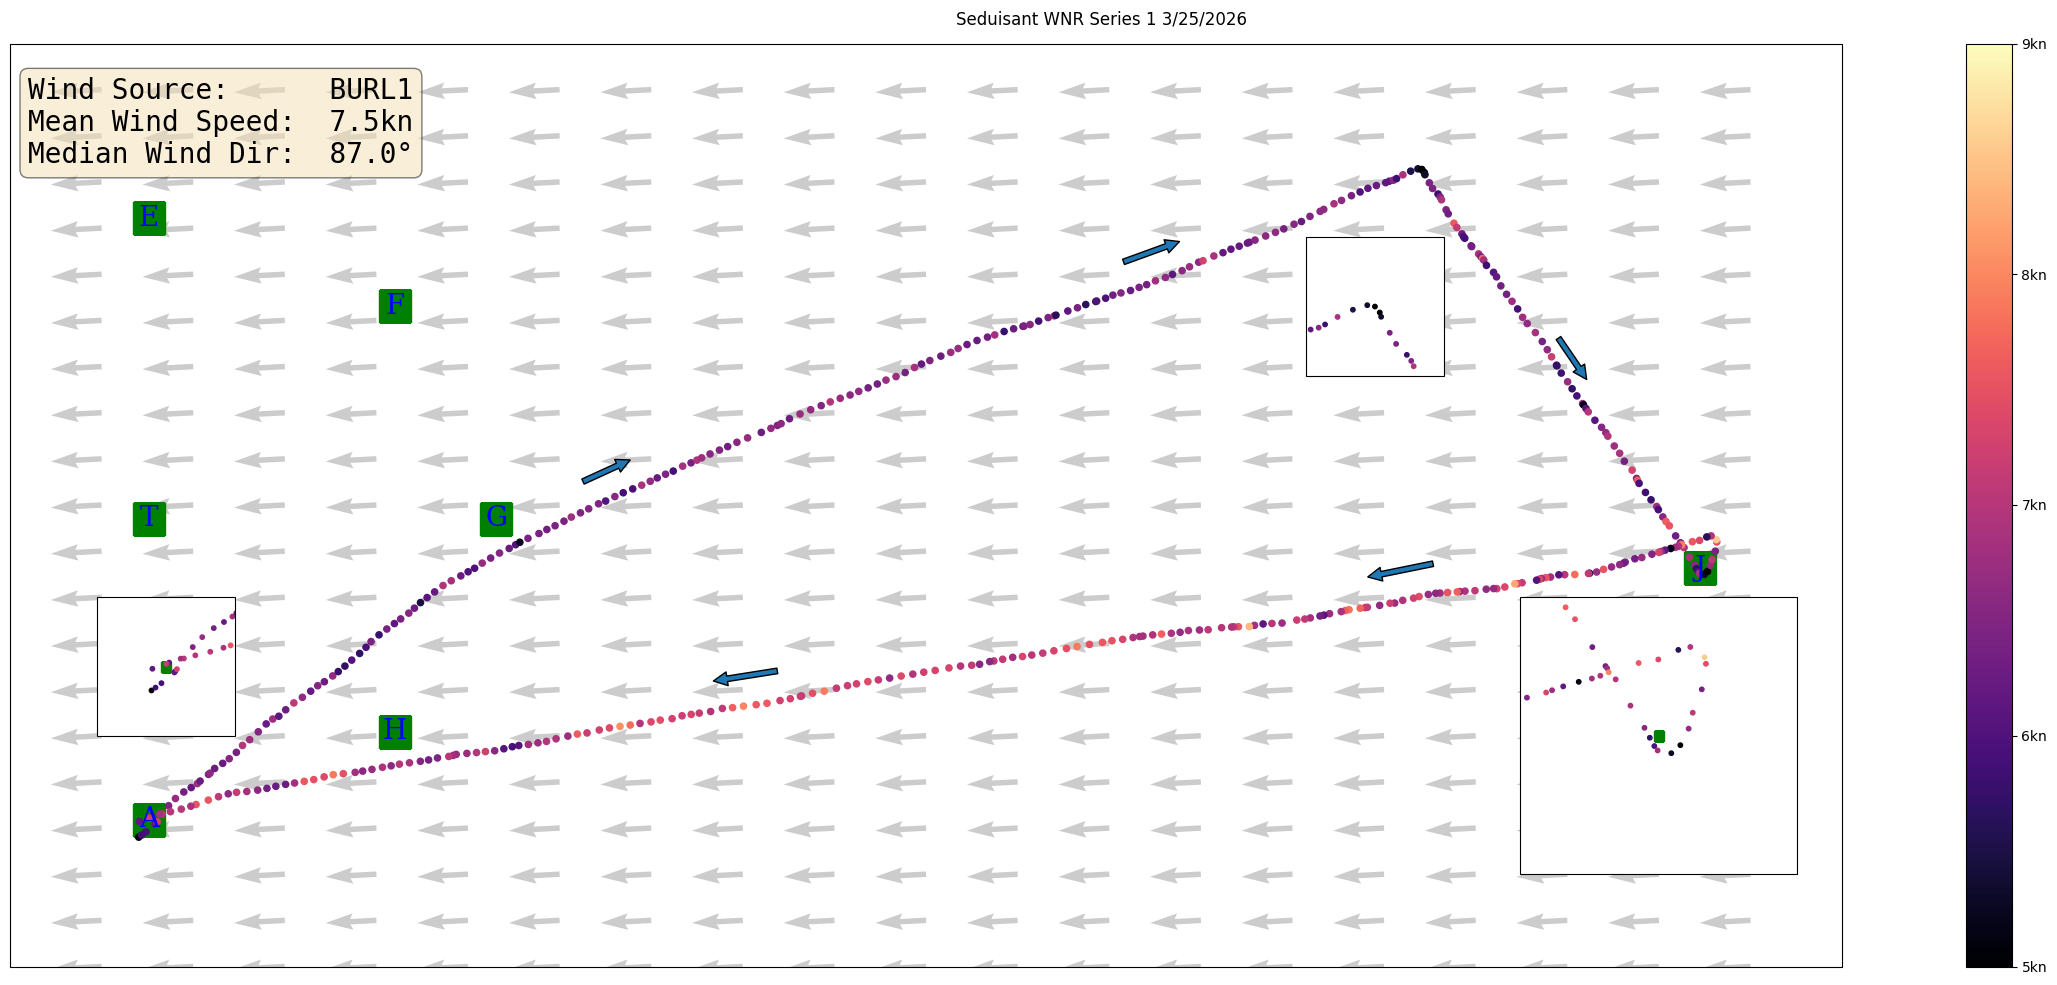

In [31]:
fig,ax = plt.subplots(1, figsize=figsize ,subplot_kw={'projection': proj})

cax = fig.colorbar( plt.cm.ScalarMappable(norm=norm, cmap=colorMap), ax=ax)
    
cax.set_ticks(colorbarTicks)
cax.set_ticklabels( [f"{int(i)}kn" for i in colorbarTicks])

createPlot(ax,s=20, extent=trkGdf.total_bounds)


wptRadius = 0.1 / 60
jExtent = waypointGdf.loc['J','geometry'].buffer(wptRadius).bounds
jInset = ax.inset_axes([0.75,0.10,0.3,0.3], projection=proj, zorder=10 )
createPlot(jInset, jExtent, s=10, wpS=50, plotWind=False, lblWpt=False, extentBuffer=0 )

tackRadius = 0.07 / 60
tackExtent = trkGdf.loc[tackPt,'geometry'].buffer(tackRadius).bounds
tackInset = ax.inset_axes([0.67,0.64,0.15,0.15], projection=proj, zorder=10 )
createPlot(tackInset, tackExtent, s=10, wpS=50, plotWind=False, lblWpt=False, extentBuffer=0 )

aExtent = waypointGdf.loc['A','geometry'].buffer(wptRadius).bounds
aInset = ax.inset_axes([0.01,0.25,0.15,0.15], projection=proj, zorder=10 )
createPlot(aInset, aExtent, s=10, wpS=50, plotWind=False, lblWpt=False, extentBuffer=0 )

#add wind speed
windStr = f"""Wind Source:      BURL1
Mean Wind Speed:  {meanWindSpeed:.1f}kn
Median Wind Dir:  {medianWind}\U000000B0"""
ax.text(0.01,0.87,windStr, transform=ax.transAxes,\
        fontsize=20,\
        fontfamily='monospace',\
       bbox={
           'boxstyle':'round',
           'facecolor':'wheat',
           'alpha':0.5
       })

fig.suptitle(title)
fig.tight_layout()
fig.savefig(f"{outputPath}/{outfileBase}.jpg")
fig.savefig(f"{outputPath}/{outfileBase}.svg")

In [32]:
trkGdfUtm = trkGdf.to_crs(utm)

In [33]:
trkGdf.columns

Index(['geometry', 'timeDelta', 'timeCumsum', 'bearing', 'delta_distance',
       'dist_cumsum', 'speed', 'majorMove'],
      dtype='str')

In [34]:
tackTime = pd.to_datetime(tackPt)
tackTimeDelta = pd.Timedelta('8 minute')
print(f"Tack time: {tackTime}")

beforeTackMask = (trkGdfUtm.index > (tackTime - tackTimeDelta)) &\
                 (trkGdfUtm.index <= tackTime)
afterTackMask = (trkGdfUtm.index < (tackTime + tackTimeDelta)) &\
                (trkGdfUtm.index >= tackTime)

nearTackMask = numpy.logical_or(beforeTackMask, afterTackMask)

nearTackDist = trkGdfUtm.loc[beforeTackMask,'geometry'].distance(trkGdfUtm.loc[tackPt,'geometry']).max()


print(f"Points before: {numpy.count_nonzero(beforeTackMask)}\tafter: {numpy.count_nonzero(afterTackMask)} tack")
print(f"Heading Range:  {trkGdfUtm.loc[nearTackMask,'bearing'].min():.0f} / {trkGdfUtm.loc[nearTackMask,'bearing'].max():.0f}")
print(f"Max distance from tack:  {nearTackDist}")

Tack time: 2026-03-25 19:04:51-05:00
Points before: 58	after: 62 tack
Heading Range:  55 / 165
Max distance from tack:  1524.0651303541347


In [35]:
def getFit(mask):
    return numpy.polyfit(trkGdfUtm[mask]['geometry'].x,trkGdfUtm[mask]['geometry'].y, 1)

beforeTackFit = getFit(beforeTackMask)
afterTackFit = getFit(afterTackMask)

In [36]:
utmTrans = pyproj.transformer.Transformer.from_crs(crs_from=utm, crs_to=wgs84)

def lineFromFit(tackFit, pts):
    outYs = []
    for pt in pts:
        y = pt * tackFit[0] + tackFit[1]
        outYs.append(y)

    return utmTrans.transform(pts,outYs)
    
utmBounds = trkGdfUtm[ nearTackMask ] .total_bounds

beforeTackLine = lineFromFit(beforeTackFit, [utmBounds[0], trkGdfUtm.loc[tackPt,'geometry'].x])
afterTackLine = lineFromFit(afterTackFit, [trkGdfUtm.loc[tackPt,'geometry'].x,utmBounds[2]])

In [37]:
def getBearing(tackLine):
    bearing = geod.inv(lons1=tackLine[1][0], lats1=tackLine[0][0],\
                         lons2=tackLine[1][1], lats2=tackLine[0][1])[0]
    if bearing < 0:
        bearing += 180 

    return bearing
    
beforeTackBearing = getBearing(beforeTackLine)
afterTackBearing = getBearing(afterTackLine)

In [38]:
print(f"Bearing before tack:  {beforeTackBearing:.0f}")
print(f"Bearing after tack:  {afterTackBearing:.0f}")

Bearing before tack:  65
Bearing after tack:  149


In [39]:
tackAngle = afterTackBearing - beforeTackBearing
print(f"Tack angle: {tackAngle:.0f}")
print(f"Angle to windward:  {tackAngle / 2.0:.0f}")

Tack angle: 83
Angle to windward:  42


In [40]:
def returnLines(loc, bearing, dist=int(nearTackDist)):
    fwdLine = geod.fwd_intermediate(loc[0][0], loc[1][0], bearing, del_s=1, npts=dist, return_back_azimuth=False, initial_idx=0)
    backLine = geod.fwd_intermediate(loc[0][0], loc[1][0], bearing-180, del_s=1, npts=dist, return_back_azimuth=False, initial_idx=0)
    return (fwdLine, backLine)

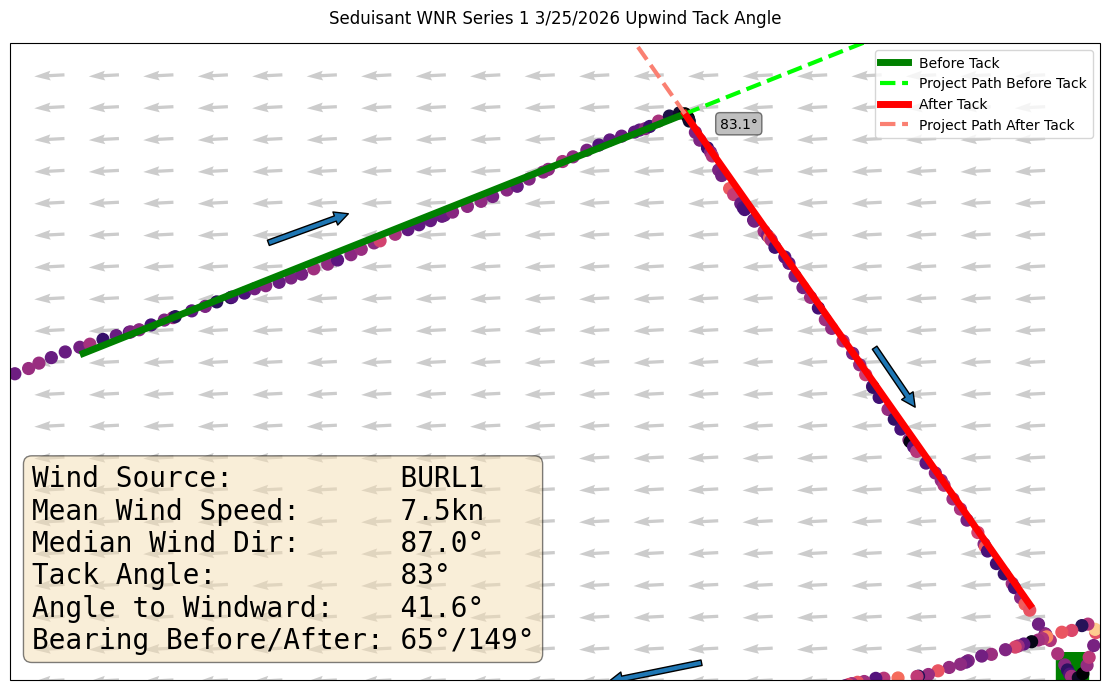

In [41]:
fig,ax = plt.subplots(1, figsize=(12,7) ,subplot_kw={'projection': proj})
extent = trkGdf[numpy.logical_or(beforeTackMask, afterTackMask)].total_bounds
createPlot(ax, extent=extent, extentBuffer=0.1/60)

tackPtLoc = trkGdf.loc[tackPt, 'geometry'].xy
fwdLine, backLine = returnLines(tackPtLoc, beforeTackBearing)
ax.plot(backLine.lons, backLine.lats, label='Before Tack', c='green', lw=5)
ax.plot(fwdLine.lons, fwdLine.lats, label='Project Path Before Tack', c='lime', lw=3, ls='--')

fwdLine, backLine = returnLines(tackPtLoc, afterTackBearing)
ax.plot(fwdLine.lons, fwdLine.lats, label='After Tack', c='red',lw=5)
ax.plot(backLine.lons, backLine.lats, label='Project Path After Tack', c='salmon', lw=3,ls='--')

windStr = f"""Wind Source:          BURL1
Mean Wind Speed:      {meanWindSpeed:.1f}kn
Median Wind Dir:      {medianWind}\U000000B0
Tack Angle:           {tackAngle:.0f}\U000000B0
Angle to Windward:    {tackAngle/2.0:.1f}\U000000B0
Bearing Before/After: {beforeTackBearing:.0f}\U000000B0/{afterTackBearing:.0f}\U000000B0"""
ax.text(0.02,0.05,windStr, transform=ax.transAxes,\
        fontsize=20,\
        family='monospace',\
       bbox={
           'boxstyle':'round',
           'facecolor':'wheat',
           'alpha':0.5
       })

ax.text(tackPtLoc[0][0]+(0.05/60), tackPtLoc[1][0]-(0.02/60),f"{tackAngle:.1f}\U000000B0",\
       bbox={
           'boxstyle':'round',
           'facecolor':'grey',
           'alpha':0.5
       })

ax.legend()

fig.suptitle(f"{title} Upwind Tack Angle")

fig.tight_layout()
fig.savefig(f"{outputPath}/{outfileBase}_TackAngles.jpg")
fig.savefig(f"{outputPath}/{outfileBase}_TackAngles.svg")

In [42]:
print(f"Last run:  {datetime.now()}")

Last run:  2026-04-15 09:49:49.313879
